# StresSense — 1D CNN Training

Run `01_preprocessing.ipynb` first. This notebook trains the quantization-friendly 1D CNN and evaluates it on the held-out test user.

In [1]:
from pathlib import Path
import json
import os
from IPython.display import Image, display

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_DIR)
print('Working directory:', PROJECT_DIR)

Working directory: /Users/jaloliddinabdullaev/Projects/activity-recognition-training/stresssense


## Training configuration

Training uses early stopping. It may finish before the maximum epoch count.

In [2]:
EPOCHS = 120
BATCH_SIZE = 32
SEED = 42
AUGMENTATION_COPIES = 1

In [3]:
import sys
import train

sys.argv = [
    'train.py',
    '--epochs', str(EPOCHS),
    '--batch-size', str(BATCH_SIZE),
    '--seed', str(SEED),
    '--augmentation-copies', str(AUGMENTATION_COPIES),
]
train.main()

Matplotlib is building the font cache; this may take a moment.
2026-06-25 00:15:39.518401: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-06-25 00:15:39.518434: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-25 00:15:39.518447: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-06-25 00:15:39.519029: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-25 00:15:39.519494: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv1D)              (None, 250, 32)           1312      
                                                                 
 pool1 (MaxPooling1D)        (None, 125, 32)           0         
                                                                 
 drop1 (Dropout)             (None, 125, 32)           0         
                                                                 
 conv2 (Conv1D)              (None, 125, 64)           10304     
                                                                 
 pool2 (MaxPooling1D)        (None, 62, 64)            0         
                                                                 
 drop2 (Dropout)             (None, 62, 64)            0         
                                                                 
 conv3 (Conv1D)              (None, 62, 64)            1

2026-06-25 00:15:40.194593: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-06-25 00:15:49.833907: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


520/520 - 10s - loss: 0.4909 - accuracy: 0.8268 - val_loss: 0.5296 - val_accuracy: 0.8052 - lr: 0.0010 - 10s/epoch - 20ms/step
Epoch 2/120
520/520 - 9s - loss: 0.2596 - accuracy: 0.9134 - val_loss: 0.5092 - val_accuracy: 0.8028 - lr: 0.0010 - 9s/epoch - 17ms/step
Epoch 3/120
520/520 - 9s - loss: 0.2198 - accuracy: 0.9280 - val_loss: 0.5641 - val_accuracy: 0.8192 - lr: 0.0010 - 9s/epoch - 17ms/step
Epoch 4/120
520/520 - 9s - loss: 0.1968 - accuracy: 0.9367 - val_loss: 0.4701 - val_accuracy: 0.8427 - lr: 0.0010 - 9s/epoch - 17ms/step
Epoch 5/120
520/520 - 9s - loss: 0.1725 - accuracy: 0.9468 - val_loss: 0.3600 - val_accuracy: 0.8803 - lr: 0.0010 - 9s/epoch - 17ms/step
Epoch 6/120
520/520 - 9s - loss: 0.1618 - accuracy: 0.9489 - val_loss: 0.3280 - val_accuracy: 0.8920 - lr: 0.0010 - 9s/epoch - 17ms/step
Epoch 7/120
520/520 - 9s - loss: 0.1499 - accuracy: 0.9525 - val_loss: 0.3931 - val_accuracy: 0.8568 - lr: 0.0010 - 9s/epoch - 17ms/step
Epoch 8/120
520/520 - 9s - loss: 0.1388 - accuracy:

2026-06-25 00:21:55.784910: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
/opt/homebrew/Caskroom/miniforge/base/envs/tinyml2/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



               precision    recall  f1-score   support

       eating      0.795     0.750     0.772        88
   face_touch      1.000     1.000     1.000        58
  nail_biting      0.976     1.000     0.988       121
      smoking      0.983     0.642     0.777       176
staying_still      0.500     1.000     0.667        63

     accuracy                          0.832       506
    macro avg      0.851     0.878     0.841       506
 weighted avg      0.890     0.832     0.838       506

Cross-user float accuracy: 83.20%


In [5]:
metrics = json.loads((PROJECT_DIR / 'results/metrics.json').read_text())
print(f"Float cross-user accuracy: {metrics['test_accuracy'] * 100:.2f}%")
print(f"Best validation accuracy: {metrics['best_val_accuracy'] * 100:.2f}%")
print(f"Epochs trained: {metrics['epochs_trained']}")
print(f"Parameters: {metrics['total_params']:,}")

Float cross-user accuracy: 83.20%
Best validation accuracy: 92.25%
Epochs trained: 39
Parameters: 28,453


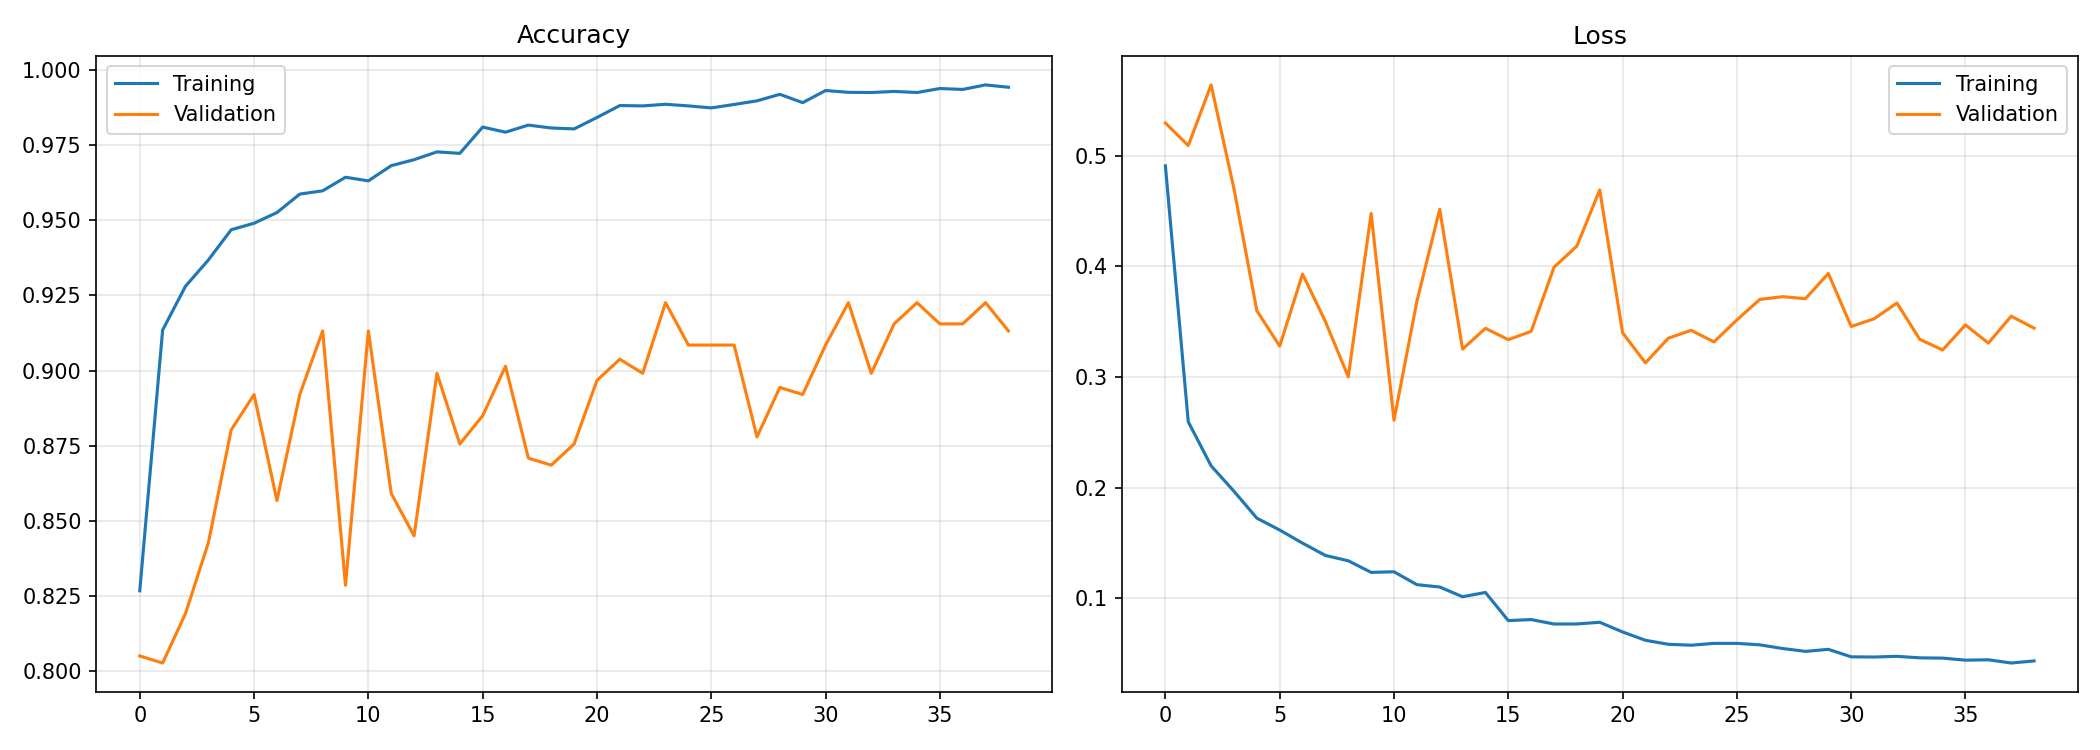

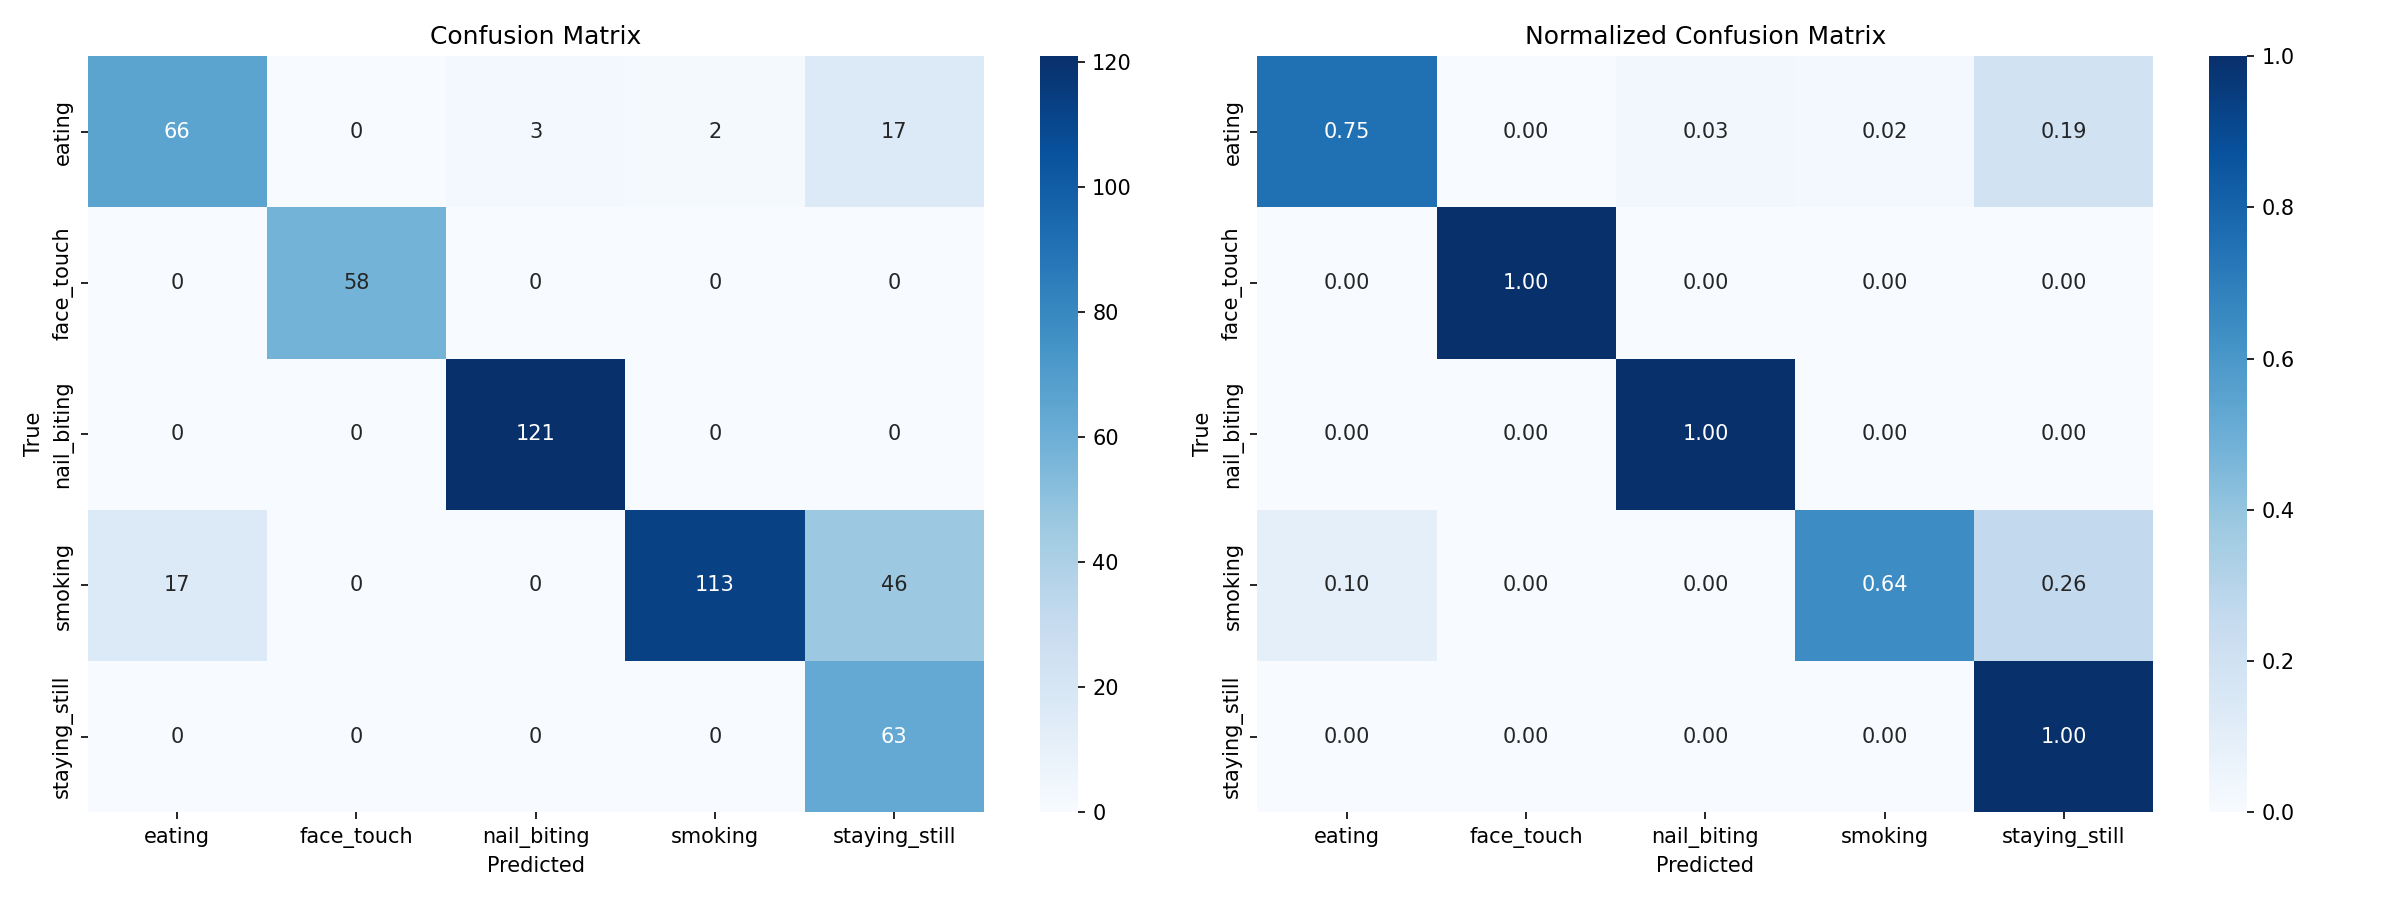

In [6]:
display(Image(filename=str(PROJECT_DIR / 'results/training_history.png')))
display(Image(filename=str(PROJECT_DIR / 'results/confusion_matrix.png')))

In [7]:
print((PROJECT_DIR / 'results/classification_report.txt').read_text())

               precision    recall  f1-score   support

       eating      0.795     0.750     0.772        88
   face_touch      1.000     1.000     1.000        58
  nail_biting      0.976     1.000     0.988       121
      smoking      0.983     0.642     0.777       176
staying_still      0.500     1.000     0.667        63

     accuracy                          0.832       506
    macro avg      0.851     0.878     0.841       506
 weighted avg      0.890     0.832     0.838       506

